In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def getCSVData(fileName):
    data_pd = pd.read_csv(fileName, sep="\t")
    data_pd["<DATETIME>"] = data_pd["<DATE>"] + " " + data_pd["<TIME>"]
    data_pd.drop(columns=["<DATE>", "<TIME>"], inplace=True)
    data_pd["<DATETIME>"] = pd.to_datetime(data_pd["<DATETIME>"], errors='coerce')
    data_pd = data_pd.set_index("<DATETIME>")
    data_pd = data_pd[data_pd.index.dayofweek < 5]
    return data_pd

def DEMA(series, period):
    ema = series.ewm(span=period, adjust=False).mean()
    dema = 2 * ema - ema.ewm(span=period).mean()
    return dema

def drawGraph(data=[], y=[], y1=[], y2=[], buy=[], sell=[], title="", 
              label = "" , label1 = "", label2 = "", xlabel="", ylabel="", 
              sl =[], tp=[], stop_loss = [], take_profit = []):
    
    plt.figure(figsize = (50, 6))
    x = range(len(data))
    plt.plot(x, y, label = label)
    if(len(y1) > 0):
        plt.plot(x, y1, label = label1)
    if(len(y2) > 0):
        plt.plot(x, y2, label = label2)

    if(len(sl) > 0):
        plt.plot(x, sl, linestyle="--", markersize = 10, label = "stop-loss")

    if(len(tp) > 0):
        plt.plot(x, tp, linestyle="--", markersize = 10, label = "take-profit")

    step = len(x) // 20
    plt.xticks(
        range(0, len(data), step),
        [data.index[i].strftime('%Y-%m-%d') for i in range(0, len(data), step)],
        rotation=45,
        fontsize = 15
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(x[0], x[-1])

    if len(buy) > 0:
        plt.plot([x[i] for i in buy], data["<CLOSE>"].iloc[buy],
            marker="^", linestyle="", color="green", markersize=12, label="Pirkti, DEMA1 kirto iš viršaus DEMA2")
    if len(sell) > 0:
        plt.plot([x[i] for i in sell], data["<CLOSE>"].iloc[sell],
            marker="v", linestyle="", color="red", markersize=12, label="Parduoti, DEMA1 kirto iš apačios DEMA2")
    if len(stop_loss) > 0:
        plt.plot([x[i] for i in stop_loss], data["<CLOSE>"].iloc[stop_loss],
                marker="*", linestyle="", color="orange", markersize=12, label="Parduoti, Stop-loss aktyvuotas")
    if len(take_profit) > 0:
        plt.plot([x[i] for i in take_profit], data["<CLOSE>"].iloc[take_profit],
                marker="*", linestyle="", color="black", markersize=12, label="Parduoti, take-profit aktyvuotas")
    plt.grid()
    plt.legend()
    plt.show()

def sharpeRatio(profits, periods_per_year=252):
    profits = np.array(profits)
    if len(profits) == 0:
        return 0.0
    
    mean = np.mean(profits)
    std = np.std(profits)
    
    if std == 0:
        return 0.0
    
    return (mean / std) * np.sqrt(periods_per_year)

def drawMultiGraph(data, y, y1, title, label1, label2, color1, color2, xlabel, ylabel):
    x = range(len(data))
    
    fig, axs = plt.subplots(2, 1, figsize=(30, 6))
    fig.suptitle(title, fontsize=16)
    step = len(x) // 20

    axs[0].plot(x, y, label=label1, color=color1)
    axs[0].set_ylabel(ylabel)
    axs[0].legend()
    axs[0].set_xlim(x[0], x[-1])
    axs[0].set_xticks(
        range(0, len(data), step),
        [data.index[i].strftime('%Y-%m-%d') for i in range(0, len(data), step)],
        rotation=45,
        fontsize = 15
    )
    
    axs[1].plot(x, y1, label=label2, color=color2)
    axs[1].set_xlabel(xlabel)
    axs[1].set_ylabel(ylabel)
    axs[1].legend()
    axs[1].set_xlim(x[0], x[-1])

    axs[1].set_xticks(
        range(0, len(data), step),
        [data.index[i].strftime('%Y-%m-%d') for i in range(0, len(data), step)],
        rotation=45,
        fontsize = 15
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def runStrategy(data, period1, period2, show = False):
    DEMA1 = DEMA(data["<CLOSE>"], period1)
    DEMA2 = DEMA(data["<CLOSE>"], period2)

    buy_signals = []
    sell_signals = []

    profits = pd.Series(np.zeros(len(data)))
    stop_loss = np.full(len(data), np.nan)
    take_profit = np.full(len(data), np.nan)

    profitPercent = 4
    lossPercent = 2

    current_tp = np.nan
    current_sl = np.nan

    take_profit_signals = []
    stop_loss_signals = []

    tax = 0.05

    poz = 0
    for i in range(max(period1, period2), len(data)):
        entry = False
        slippage = 0.5 * (data["<HIGH>"].iloc[i] - data["<LOW>"].iloc[i]) / 100
        profit = (data["<CLOSE>"].iloc[i] - data["<CLOSE>"].iloc[i - 1]) * poz

        commission_fee = abs(profit) * tax
        slippage_fee = abs(slippage)

        profits.iloc[i] = profit - commission_fee - slippage_fee if profit > 0 else profit

        if DEMA1.iloc[i] >= DEMA2.iloc[i] and DEMA1.iloc[i - 1] < DEMA2.iloc[i - 1] and (poz == -1 or poz == 0):
            buy_signals.append(i)
            poz = 1
            entry = True
            
        if DEMA1.iloc[i] < DEMA2.iloc[i] and DEMA1.iloc[i - 1] >= DEMA2.iloc[i - 1] and poz == 1:
            sell_signals.append(i)
            poz = -1
            entry = True

        if entry:
            current_tp = data["<CLOSE>"].iloc[i] * (1 + profitPercent / 100)
            current_sl = data["<CLOSE>"].iloc[i] * (1 - lossPercent / 100)

        take_profit[i] = current_tp
        stop_loss[i] = current_sl

        if data["<CLOSE>"].iloc[i] >= current_tp and data["<CLOSE>"].iloc[i - 1] < current_tp and poz == 1:
            take_profit_signals.append(i)
            poz = -1

        if data["<CLOSE>"].iloc[i] <= current_sl and data["<CLOSE>"].iloc[i - 1] > current_sl and poz == 1:
            stop_loss_signals.append(i)
            poz = -1

    if show:
        sl = pd.Series(stop_loss, index=data.index)
        tp = pd.Series(take_profit, index=data.index)

        drawGraph(data = data, y = data["<CLOSE>"], y1 = DEMA1, y2 = DEMA2, label = "Close kaina", buy = buy_signals, 
                sell = sell_signals, title = "Pirkimo strategija", xlabel = "Data",
                label1 = "DEMA1", label2 = "DEMA2", 
                ylabel = "Kaina", sl = sl, tp = tp, stop_loss = stop_loss_signals, take_profit = take_profit_signals)
    
    return profits

20 40


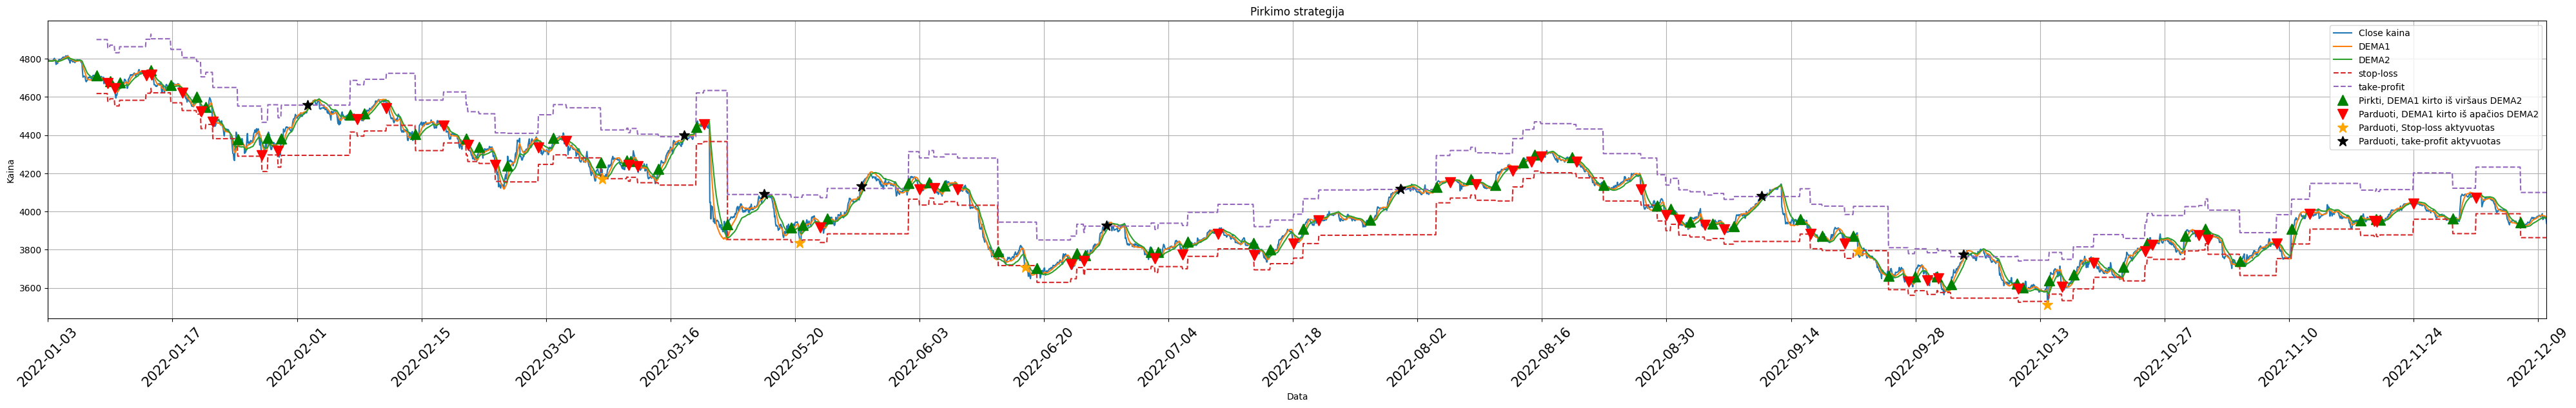

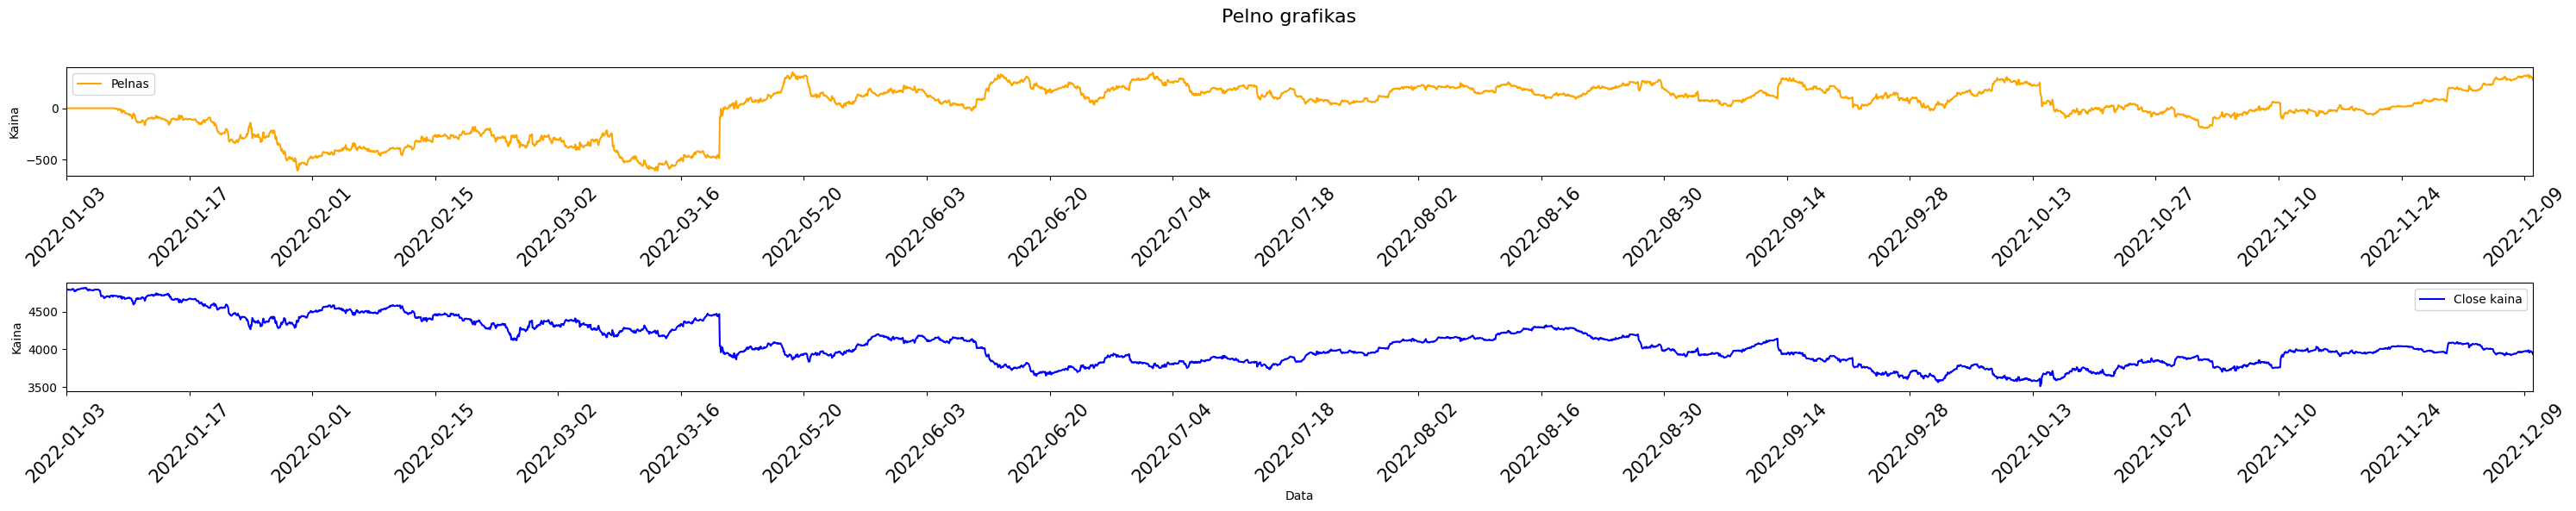

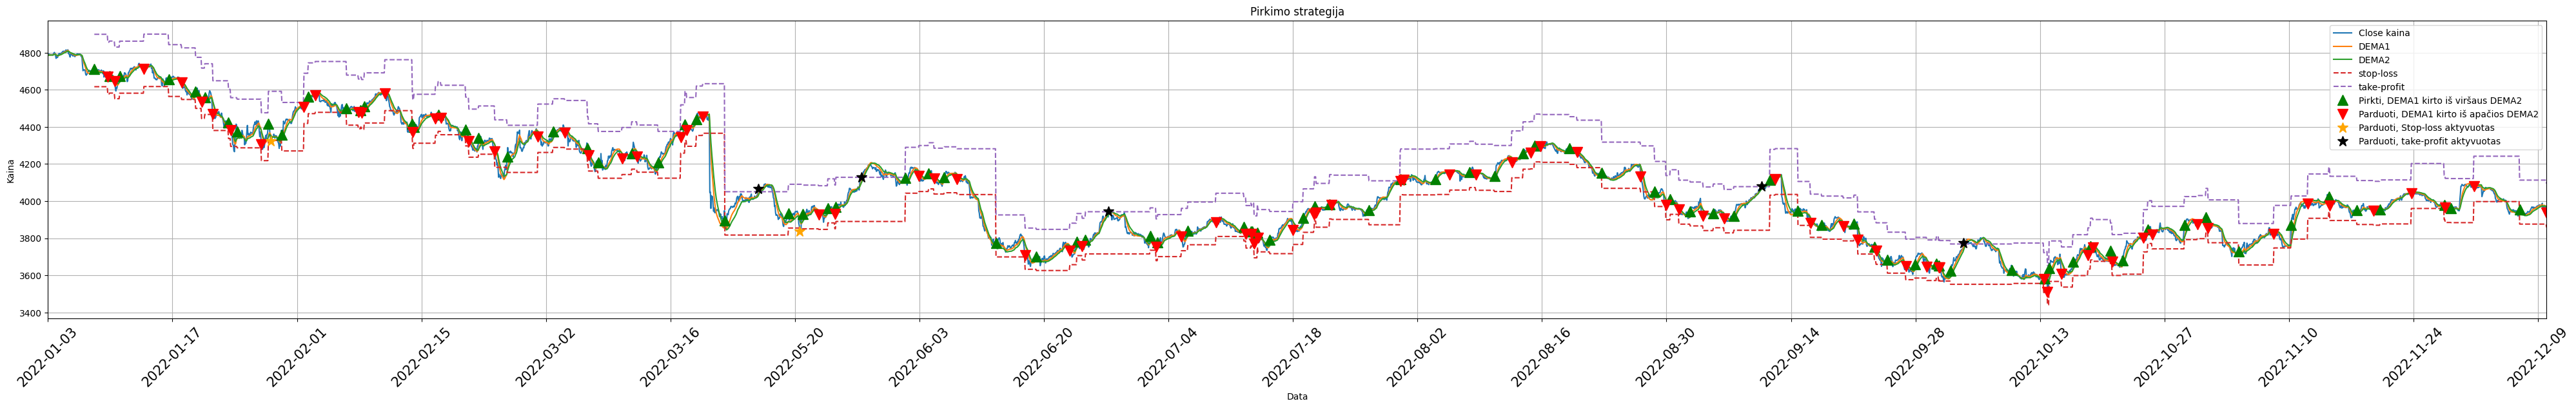

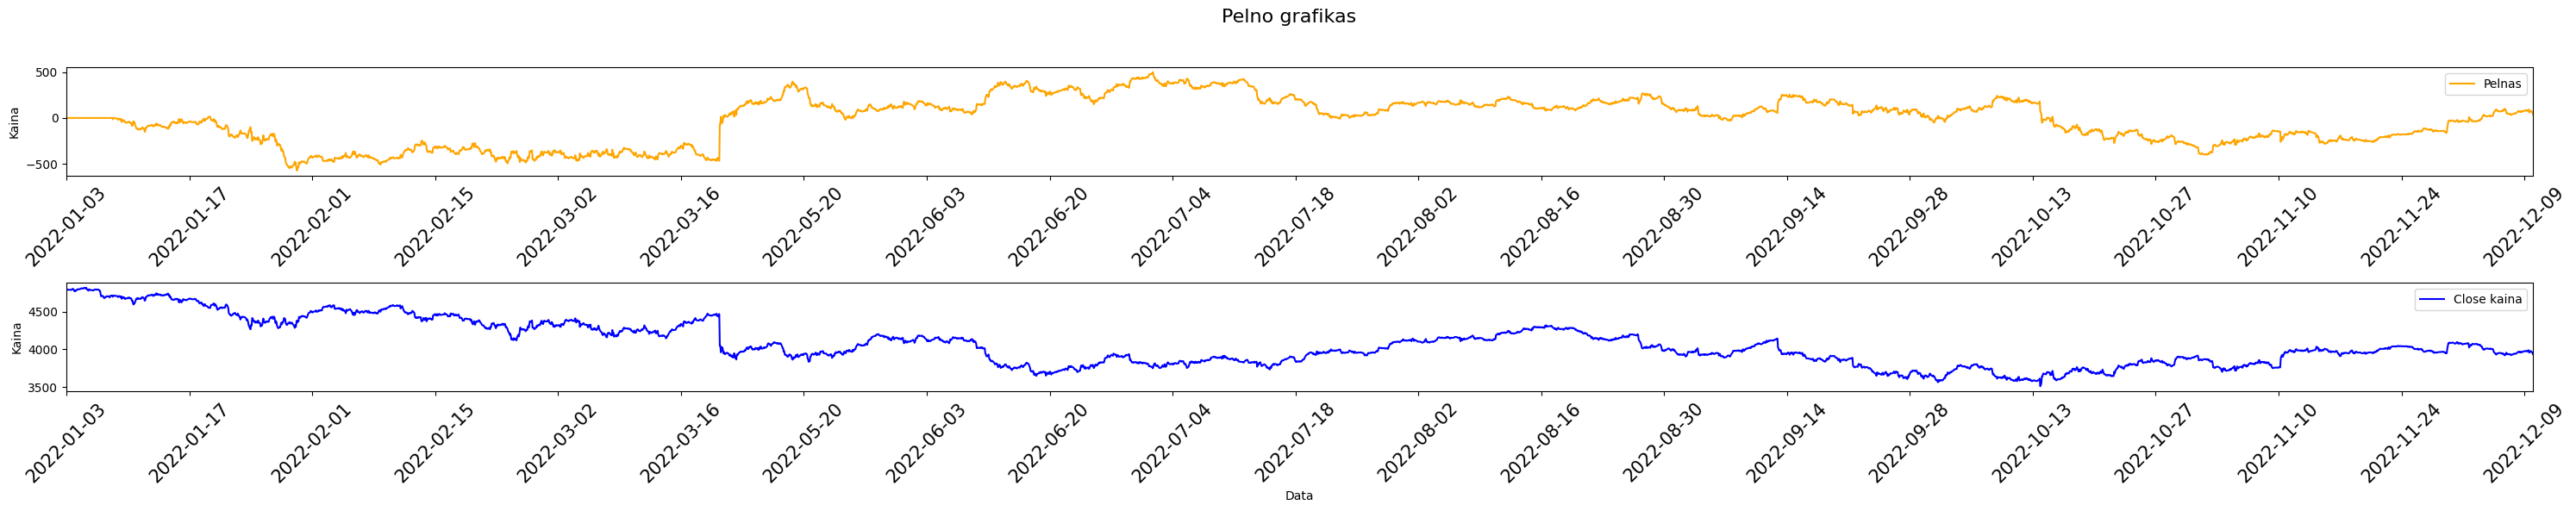

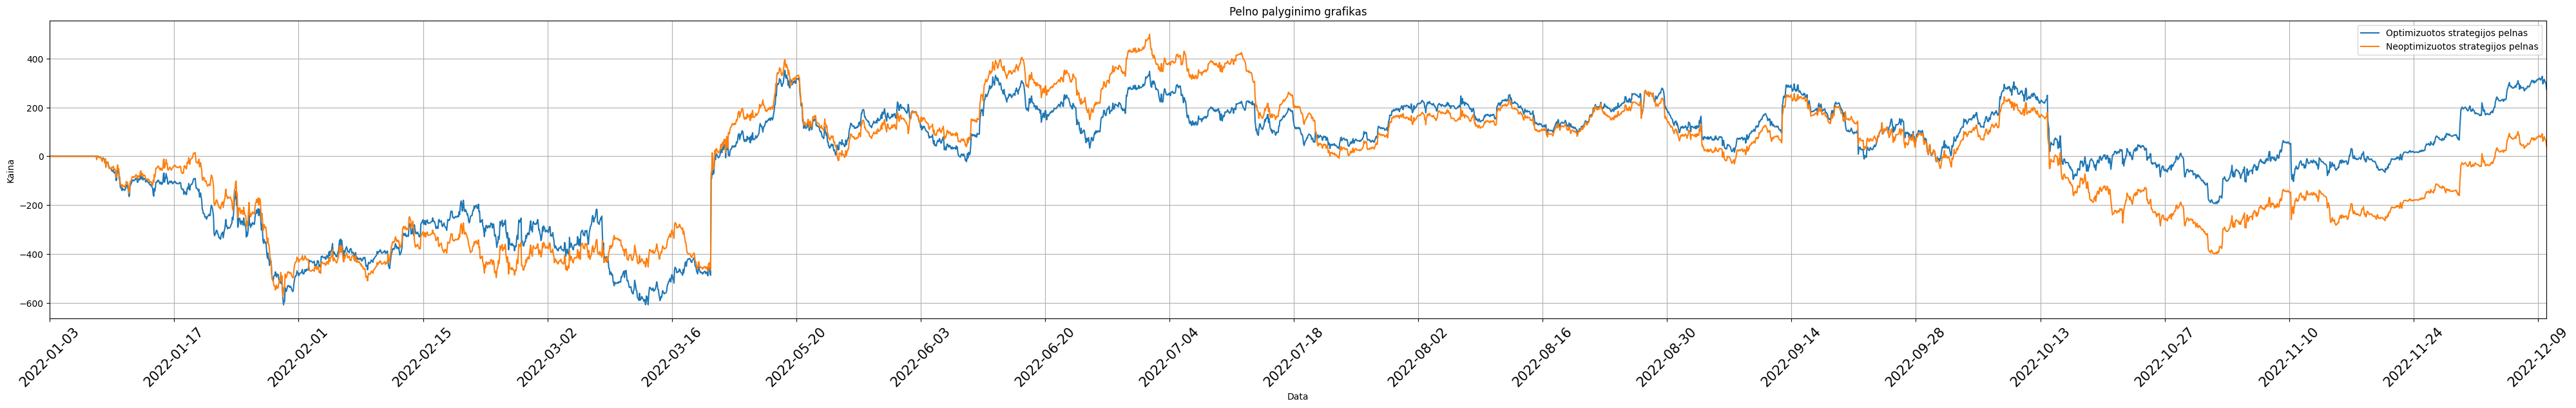

In [20]:
data = getCSVData("SPM6.csv")

MaxPeriod1 = np.nan
MaxPeriod2 = np.nan
maxSharpe = -np.inf

for period1 in range(20, 31):
    for period2 in range(40, 61):
        profits = runStrategy(data, period1, period2)
        currentSharpe = sharpeRatio(profits)
        if(currentSharpe > maxSharpe):
            maxSharpe = currentSharpe
            MaxPeriod1 = period1
            MaxPeriod2 = period2

print(MaxPeriod1, MaxPeriod2)
profits1 = runStrategy(data, MaxPeriod1, MaxPeriod2, True)
drawMultiGraph(data, profits1.cumsum(), data["<CLOSE>"], "Pelno grafikas", 
               "Pelnas", "Close kaina", "orange", "blue","Data", "Kaina")

profits2 = runStrategy(data, 20, 30, True)
drawMultiGraph(data, profits2.cumsum(), data["<CLOSE>"], "Pelno grafikas",
               "Pelnas", "Close kaina", "orange", "blue","Data", "Kaina")

drawGraph(data = data, y = profits1.cumsum(), y1 = profits2.cumsum(), 
          title = "Pelno palyginimo grafikas", label = "Optimizuotos strategijos pelnas", 
          label1 = "Neoptimizuotos strategijos pelnas", 
          ylabel = "Kaina", xlabel = "Data")